# **ETTh1: Multivariate LSTM to Univariate OT Forecasting**
---

In [26]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from torch.utils.data import DataLoader, Dataset
from torch import nn

----
## **MODEL DEFINITION**
----

In [27]:
# Hyperparameter definition w/o Optuna tuning
context  = 96       # [hours]
forecast = 96       # [hours]
batch    = 64       # [samples]
lstm_hidden_layers = 1
lstm_hidden_size   = 7
optimizer_learningrate = 0.0001
epochs = 100

### **Sample Datasets -- Clean the comments!**

The Sample_Dataset class must receive the following inputs:
- data: the dataframe containing the multivariate training time series (here, the scaled one)
- the context length and the forecast length / windows: hardcode or treat as to-be-optimized hyperparameter

In [28]:
class Sample_Dataset(Dataset):
    # A fundamental PyTorch utility: class to create data sample objects, based on a "Dataset" template parent class. Below methods __len__ and __getitem__ are inherited and required.
    # Usually implemented to create training, validation, and testing data samples with the same code, simply by adapting the data split that is fed.

    def __init__(self, data: pd.DataFrame, context_length: int, forecast_length: int):

        # Converting DataFrame to numpy for better processing 
        self.feature_data    = data.to_numpy(dtype=np.float32)          # input x -- depending on task this is either the whole training, validation or testing split
        self.target_data     = data["OT"].to_numpy(dtype=np.float32)    # prediction target y 
        
        self.context_length  = context_length       # L [hours] 
        self.forecast_length = forecast_length      # H [hours] 


    def __len__(self):
        # Total number of samples in the dataset                     
        # S = 1, timestep or stride [hours] -- delta-t by which each sample moves along the time series relative to its predecessor.

        sample_qty = (self.feature_data.shape[0] - self.context_length - self.forecast_length) + 1      # = ((T-L-H)/S)+1 | the +1 comes from considering the first sample window before a single stride was made  

        return sample_qty


    def __getitem__(self, sample_index):
        # Define what each sample looks like in terms of the data it contains: implement all data that is correlated and shall be fed to the model for learning them
        # Every sample is assigned an index, default is integers = 0, 1, 2, 3.... len(dataset)-1 : usually just called idx or index

        # x = sample input data = the full multivariate time series but restricted to the context length = only ranging from index to index + context_length (index = 0,1...!)
        x_inputs_array = self.feature_data[sample_index : (sample_index + self.context_length)]           # MIND! last value of that range is EXCLUDED, the first is INCLUDED

        # y = data of the correct correlated output that shall be predicted -- here: univariate output of OT from the data, but positioned behind the the training window and being as wide as the forecast window
        y_targets_array = self.target_data[(sample_index + self.context_length) : (sample_index + self.context_length + self.forecast_length)]     # MIND! last value of that range is EXCLUDED, the first is INCLUDED

        return torch.tensor(x_inputs_array), torch.tensor(y_targets_array)     # convert arrays into tensors for more predictable processing
        # x-tensor.shape = (batch_size, context_window, )

### **DataLoader**
- using the default class structure from PyTorch, no need for custom definitions
- batch_size fixed or optimized hyperparameter

### **Neural Net Design - LSTM**

In [29]:
class LSTM_ForecastModel(nn.Module):

    def __init__(self, num_input_features: int, lstm_width: int, lstm_depth: int, forecast_length: int):
        
        self.num_input_features = num_input_features   # multivariate input sequence: channel_number = features processed per timestep
        self.lstm_width         = lstm_width           # neurons per layer
        self.lstm_depth         = lstm_depth           # number of layers
        self.forecast_length    = forecast_length      # [hours] -- can be tuned as hyperparameter

        super().__init__()      # initializing the nn.Module parent class too

        # Store neural network elements as object attribute upon initialization
        # Input_size etc. are predefined variables.

        # LSTM part of the network
        # What shape of tensor goes in and which out?
        self.lstm_network = nn.LSTM(
            input_size   = self.num_input_features,
            hidden_size  = self.lstm_width,
            num_layers   = self.lstm_depth,
            batch_first  = True,                         # batch size = first entry in the DataLoader outputs, typically True
            # dropout     = dropout       # means roughly (20)% of the relevant activations are dropped during each training pass. can help avoid overfitting with large datasets
        )

        # Linear output layer for direct one-shot multi-timestep forecasting 
        # --> Use only the output from the last timestep as projection to accumulate info in the LSTM state, discard other outputs --> see forward()
        self.output_layer = nn.Linear(
            in_features  = self.lstm_width,          # connecting to the last LSTM layer
            out_features = self.forecast_length      # projecting to the full forcast window at the same time
        )


    def forward(self, x_inputs):
        # perform the forward pass on itself by feeding inputs x

        # from tensor from DataLoader: shape = (batch_size, context_length, num_input_features)
        
        lstm_output, _ = self.lstm_network(x_inputs)          # outut: output, (h_n, c_n) = lstm(x) // output.shape == (batch_size, context_length, hidden_size)

        # select the last output for forecasting only, but all related batches and hidden features 
        lstm_last_output = lstm_output[ : , -1, : ]    # indexation in the tensor: output[batch_index, time_index, hidden_size], starting with 0 -- means [:,context_length -1,:] or just [:,-1,:], remember counting starts with 0 so the last is context -1 

        # make the forecasting projection with the last lstm outputs to the whole forecast horizon
        y_predictions = self.output_layer(lstm_last_output)      

        return y_predictions     # shape: [batch_size, forecast_length, num_output_features = 1]

----
## **DATA PIPELINE**
----

### **Import**
The imported DataFrame has a shape of $ \mathrm{data\_ETTh1} \isin \R^{Tx7} $

In [30]:
# Import full data set from original source
url =  "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/refs/heads/main/ETT-small/ETTh1.csv"

data_ETTh1 = pd.read_csv(url, sep = ",")
data_ETTh1.set_index('date', inplace=True)

### **Splitting into Training/Validation/Test Sets**
- Using the recommended typical 12 - 4 - 4 split here, resulting in a total of 20 months of data
- The dataset contains almost 24 months, so the remaining c. 4 months get cut and are **unused**
- Validation and test datasets are extended so that x_val and x_test start in the training and validation set already

In [31]:
# Number of rows in the source ETTh1 data set
timesteps_source = data_ETTh1.shape[0]     # hours in the full length dataset (rows in the original data frame)
print("Timesteps in the source dataset: ", timesteps_source, "hours")

# Splitting into training, validation, and test splits
hours_per_month = 30 * 24           # hours

training_length   = 12 * hours_per_month         # 12 months
validation_length = 4 * hours_per_month          # 4 months
test_length       = 4 * hours_per_month          # 4 months   

# Create training, validation, and test splits
training_split    = data_ETTh1.iloc[:training_length]
validation_split  = data_ETTh1.iloc[training_length:(training_length + validation_length)]
test_split        = data_ETTh1.iloc[(training_length + validation_length):(training_length + validation_length + test_length)]
discarded_split   = data_ETTh1.iloc[(training_length + validation_length + test_length):]

timesteps = training_split.shape[0] + validation_split.shape[0] + test_split.shape[0]

print("Timesteps in the truncated split: ", timesteps, "hours")
print("Timesteps in the training split: ", training_split.shape[0], "hours")
print("Timesteps in the discarded split: ", discarded_split.shape[0], "hours")
print("The training/validation/test split relative to the truncated set [%]: ", training_split.shape[0]/timesteps*100, "/", validation_split.shape[0]/timesteps*100, "/", test_split.shape[0]/timesteps*100)

Timesteps in the source dataset:  17420 hours
Timesteps in the truncated split:  14400 hours
Timesteps in the training split:  8640 hours
Timesteps in the discarded split:  3020 hours
The training/validation/test split relative to the truncated set [%]:  60.0 / 20.0 / 20.0


In [32]:
# No changes needed
training_set = training_split   

# Extending the validation split, x_val should start at -context in the training set, so first val_prediction is the first unseen entry in the validation split (moving window, see Dataset __getitem__!)
validation_set = pd.concat([ training_split.iloc[ -context : ], validation_split])    

# Extending the testing split, respectively
test_set = pd.concat([ validation_split.iloc[ -context : ], test_split])  

# Checking the 
print(f"Validation split was extended by: {validation_set.shape[0] - validation_split.shape[0]} hours, must match the context window of {context} hours.")
print(f"Test split was extended by: {validation_set.shape[0] - validation_split.shape[0]} hours, must match the context window of {context} hours.")


Validation split was extended by: 96 hours, must match the context window of 96 hours.
Test split was extended by: 96 hours, must match the context window of 96 hours.


### **Scaling the Training Set, Fitting Validation & Test Sets for each Channel**
- Each channel has a different characteristic and must be scaled separately
- Chosing the MinMaxScaler over the StandardScaler because it allows to bound all signals to a fixed interval of magnitudes: no channel can introduce overfitting due to pure differences in magnitude --> considered "cleaner" for multivariate inputs. 
- Choosing (-1,1) as interval for the MinMaxScaler for most neutral signal processing

                         HUFL      HULL      MUFL      MULL      LUFL  \
date                                                                    
2016-07-01 00:00:00  0.159536 -0.114792  0.184901 -0.103638  0.187837   
2016-07-01 01:00:00  0.153215 -0.103859  0.179361 -0.109815  0.174397   
2016-07-01 02:00:00  0.127931 -0.158522  0.168332 -0.121997  0.093974   
2016-07-01 03:00:00  0.124770 -0.125724  0.168332 -0.115820  0.100584   
2016-07-01 04:00:00  0.137412 -0.125724  0.179361 -0.103638  0.114024   

                         LULL        OT  
date                                     
2016-07-01 00:00:00  0.227530  0.382035  
2016-07-01 01:00:00  0.241567  0.272466  
2016-07-01 02:00:00  0.172289  0.272466  
2016-07-01 03:00:00  0.199909  0.162937  
2016-07-01 04:00:00  0.199909  0.039312  


array([<Axes: xlabel='date'>, <Axes: xlabel='date'>,
       <Axes: xlabel='date'>, <Axes: xlabel='date'>,
       <Axes: xlabel='date'>, <Axes: xlabel='date'>,
       <Axes: xlabel='date'>], dtype=object)

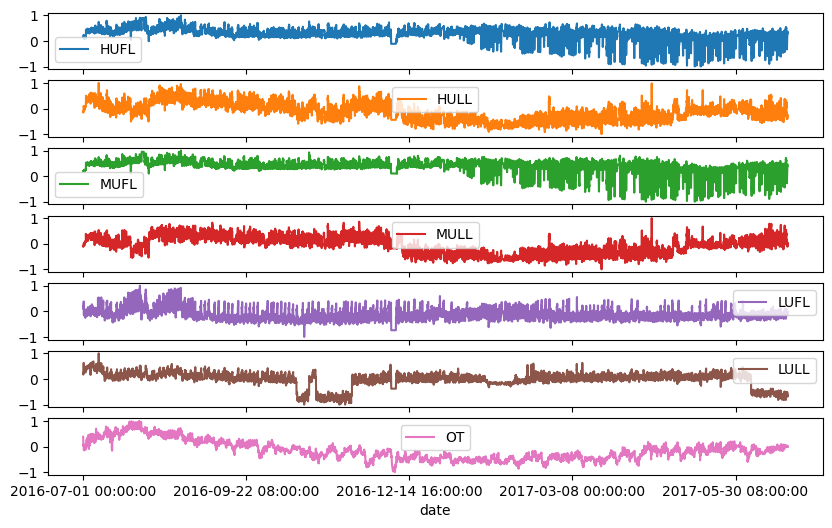

In [33]:
# Set up empty DataFrames to hold the scaled data with the right index and columns
training_set_scaled = pd.DataFrame(index=training_set.index, columns=training_set.columns)
validation_set_scaled = pd.DataFrame(index=validation_set.index, columns=validation_set.columns)
test_set_scaled = pd.DataFrame(index=test_set.index, columns=test_set.columns)

scalers_dict = {}

for column in training_set.columns:

    # Define and fit the scaler on the training set of each signal only
    scaler = MinMaxScaler(feature_range=(-1, 1))
    scaler.fit(training_set[[column]])

    # Saving all scalers for later inverse transformation of predictions
    scalers_dict[column] = scaler

    # Transform the training, validation, and test sets of each signal using the fitted scaler. All set have the same index and columns as the original data frames.
    training_set_scaled[column] = scaler.transform(training_set[[column]])
    validation_set_scaled[column] = scaler.transform(validation_set[[column]])
    test_set_scaled[column] = scaler.transform(test_set[[column]])

# Checking results of scaling
print(training_set_scaled.head())
training_set_scaled.plot(subplots=True, figsize=(10, 6))

----
## **TRAINING PIPELINE**
----

### **Data and Model Initialization**

In [34]:
# Initialize data sampling
training_dataset = Sample_Dataset(
    data            = training_set_scaled, 
    context_length  = context,
    forecast_length = forecast
)

validation_dataset = Sample_Dataset(
    data            = validation_set_scaled, 
    context_length  = context,
    forecast_length = forecast
)

test_dataset = Sample_Dataset(
    data            = test_set_scaled, 
    context_length  = context,
    forecast_length = forecast
)

# Load samples and initialize batches
training_batches = DataLoader(
    dataset    = training_dataset,
    batch_size = batch,
    shuffle    = True                   
)

validation_batches = DataLoader(
    dataset    = validation_dataset,
    batch_size = batch,
    shuffle    = False                   
)

test_batches = DataLoader(
    dataset    = test_dataset,
    batch_size = batch,
    shuffle    = False                   
)


# THIS IS JUST FOR CHECKING! The extraction is done in the loop!
# Extract batches for x_inputs and y_targets data
x_inputs_batch, y_targets_batch = next(iter(training_batches))

print("Input shape:", x_inputs_batch.shape)
print("Target shape:", y_targets_batch.shape)
print("Number of batches:", len(training_batches))



Input shape: torch.Size([64, 96, 7])
Target shape: torch.Size([64, 96])
Number of batches: 133


In [35]:
# Initialize the model

model = LSTM_ForecastModel(
    num_input_features = training_set_scaled.shape[1],  # columns in the input dataframe
    lstm_width         = lstm_hidden_size,
    lstm_depth         = lstm_hidden_layers,
    forecast_length    = forecast
)

### Print number of trainable parameters
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model has {num_params} trainable parameters.")

# Select device for computations
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Execute model on defined device
model.to(device)    

Model has 1216 trainable parameters.
Device: cpu


LSTM_ForecastModel(
  (lstm_network): LSTM(7, 7, batch_first=True)
  (output_layer): Linear(in_features=7, out_features=96, bias=True)
)

### **Loss Function & Optimization**

In [12]:
# Loss function
criterion = nn.MSELoss()

# Optimizer
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=optimizer_learningrate,
)

### **Model Training & Validation Loop**

In [13]:
training_losses = []
validation_losses = []

for epoch in range(epochs):

    # Training Step
    model.train()
    epoch_training_loss_sum = 0.0

    for x_training_batch, y_training_targets_batch in training_batches:

        x_training_batch         = x_training_batch.to(device)
        y_training_targets_batch = y_training_targets_batch.to(device)

        optimizer.zero_grad()

        y_training_predictions_batch = model(x_training_batch)

        # Calculate the training loss
        batch_training_loss = criterion(
            y_training_predictions_batch,
            y_training_targets_batch,
        )

        batch_training_loss.backward()
        optimizer.step()

        epoch_training_loss_sum += batch_training_loss.item()

    epoch_training_loss_avg = epoch_training_loss_sum / len(training_batches)     # average epoch loss per batch
    training_losses.append(epoch_training_loss_avg)


    model.eval()
    epoch_validation_loss_sum = 0.0

    with torch.no_grad():
    # disables gradient calculation, no gradients for backpropagation needed here
    
        for x_validation_batch, y_validation_targets_batch in validation_batches:
            # Note: less validation samples (shorter set), therfore less batches. all batches evaluated per epoch.

            x_validation_batch         = x_validation_batch.to(device)
            y_validation_targets_batch = y_validation_targets_batch.to(device)

            y_validation_predictions_batch = model(x_validation_batch)

            # Calculate the validation loss
            validation_batch_loss = criterion(
                y_validation_predictions_batch, 
                y_validation_targets_batch)

            epoch_validation_loss_sum += validation_batch_loss.item()

    epoch_validation_loss_avg = epoch_validation_loss_sum / len(validation_batches)
    validation_losses.append(epoch_validation_loss_avg)

    # Epochs in the model = 0,1,2 ... but usually reported as = 1,2,3
    print(
        f"Epoch: {epoch + 1:3d} | "
        f"Train loss: {epoch_training_loss_avg:.8f} | "
        f"Val loss: {epoch_validation_loss_avg:.8f}"
    )

Epoch:   1 | Train loss: 0.20771151 | Val loss: 0.13261486
Epoch:   2 | Train loss: 0.19705989 | Val loss: 0.12202670
Epoch:   3 | Train loss: 0.18552719 | Val loss: 0.11100143
Epoch:   4 | Train loss: 0.17407054 | Val loss: 0.09893505
Epoch:   5 | Train loss: 0.15751900 | Val loss: 0.08611368
Epoch:   6 | Train loss: 0.13946724 | Val loss: 0.07435198
Epoch:   7 | Train loss: 0.11869301 | Val loss: 0.06597219
Epoch:   8 | Train loss: 0.09901779 | Val loss: 0.06107342
Epoch:   9 | Train loss: 0.08476913 | Val loss: 0.05823597
Epoch:  10 | Train loss: 0.07069232 | Val loss: 0.05574484
Epoch:  11 | Train loss: 0.06118263 | Val loss: 0.05508921
Epoch:  12 | Train loss: 0.05381055 | Val loss: 0.05461476
Epoch:  13 | Train loss: 0.04817822 | Val loss: 0.05389843
Epoch:  14 | Train loss: 0.04398916 | Val loss: 0.05191361
Epoch:  15 | Train loss: 0.04073614 | Val loss: 0.05061123
Epoch:  16 | Train loss: 0.03781111 | Val loss: 0.04940791
Epoch:  17 | Train loss: 0.03520079 | Val loss: 0.047659

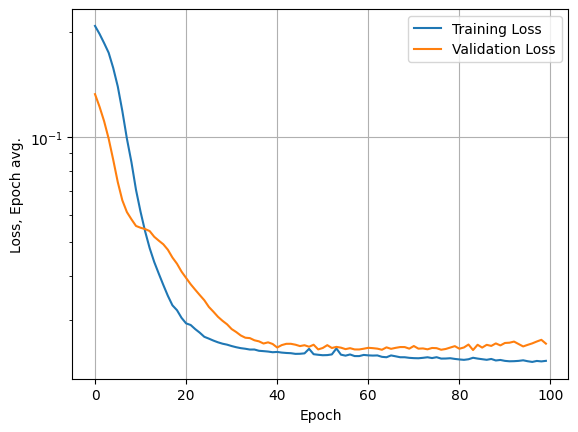

In [ ]:
# Plot loss curve
plt.plot(training_losses, label = "Training Loss")
plt.plot(validation_losses, label = "Validation Loss")
plt.ylabel("Loss, Epoch avg.")
plt.xlabel("Epoch")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.show()

### **Retraining with Optimized Parameters**

In [29]:
epochs_ideal = 60

training_losses = []
validation_losses = []

for epoch in range(epochs_ideal):

    # Training Step
    model.train()
    epoch_training_loss_sum = 0.0

    for x_training_batch, y_training_targets_batch in training_batches:

        x_training_batch         = x_training_batch.to(device)
        y_training_targets_batch = y_training_targets_batch.to(device)

        optimizer.zero_grad()

        y_training_predictions_batch = model(x_training_batch)

        batch_training_loss = criterion(
            y_training_predictions_batch,
            y_training_targets_batch,
        )

        batch_training_loss.backward()
        optimizer.step()

        epoch_training_loss_sum += batch_training_loss.item()

    epoch_training_loss_avg = epoch_training_loss_sum / len(training_batches)     # average epoch loss per batch
    training_losses.append(epoch_training_loss_avg)


    model.eval()
    epoch_validation_loss_sum = 0.0

    with torch.no_grad():
    # disables gradient calculation, no gradients for backpropagation needed here
    
        for x_validation_batch, y_validation_targets_batch in validation_batches:

            x_validation_batch         = x_validation_batch.to(device)
            y_validation_targets_batch = y_validation_targets_batch.to(device)

            y_validation_predictions_batch = model(x_validation_batch)
            
            validation_batch_loss = criterion(
                y_validation_predictions_batch, 
                y_validation_targets_batch)

            epoch_validation_loss_sum += validation_batch_loss.item()

    epoch_validation_loss_avg = epoch_validation_loss_sum / len(validation_batches)
    validation_losses.append(epoch_validation_loss_avg)

### **Exporting Model Weights**

In [ ]:
# torch.save(model.state_dict(), "LSTM_1x7_weights.pt")

: 

----
## **Model Testing**
----

### **Generating Predictions**

In [ ]:
y_test_targets_scaled = []
y_test_predictions_scaled = []

# Start testing   
model.eval()

with torch.no_grad():

    for x_test_batch, y_test_targets_batch in test_batches:

        x_test_batch        = x_test_batch.to(device)

        # Make the prediction
        y_test_predictions_batch = model(x_test_batch)
        
        # Collect all y_prediction and y_target batches simultaneously (also works whenthe batches are shuffled)
        y_test_predictions_scaled.append(y_test_predictions_batch.cpu().numpy())
        y_test_targets_scaled.append(y_test_targets_batch.cpu().numpy())


# Transform the collection of np.arrays to a single array for error calculation
y_test_predictions_scaled = np.concatenate(y_test_predictions_scaled, axis=0)
y_test_targets_scaled = np.concatenate(y_test_targets_scaled, axis=0)

# Convert predictions back to source scale
y_test_predictions = scaler.inverse_transform(y_test_predictions_scaled)
y_test_targets = scaler.inverse_transform(y_test_targets_scaled)

In [ ]:
print(f"Predictions.shape: {y_test_predictions.shape}")

# Selecting one of the prediction time series from all concatenated batches. Needs shape = (96,) to match time dimension for plotting
print(f"Targets.shape: {y_test_targets[0].shape}")

NameError: name 'y_test_predictions' is not defined

### **Metrics**

In [47]:
### Metrics
test_mse = mean_squared_error(y_test_targets, y_test_predictions)
test_mae = mean_absolute_error(y_test_targets, y_test_predictions)


print(f"\nTest MSE: {test_mse:.8f}")
print(f"Test MAE: {test_mae:.8f}")


Test MSE: 56.98784256
Test MAE: 6.78056955


### **Plotting**

In [35]:
# Create time axis
time = np.arange((training_length + validation_length + context), (training_length + validation_length + context + forecast), 1)

print(time)
print(time.shape)

[11616 11617 11618 11619 11620 11621 11622 11623 11624 11625 11626 11627
 11628 11629 11630 11631 11632 11633 11634 11635 11636 11637 11638 11639
 11640 11641 11642 11643 11644 11645 11646 11647 11648 11649 11650 11651
 11652 11653 11654 11655 11656 11657 11658 11659 11660 11661 11662 11663
 11664 11665 11666 11667 11668 11669 11670 11671 11672 11673 11674 11675
 11676 11677 11678 11679 11680 11681 11682 11683 11684 11685 11686 11687
 11688 11689 11690 11691 11692 11693 11694 11695 11696 11697 11698 11699
 11700 11701 11702 11703 11704 11705 11706 11707 11708 11709 11710 11711]
(96,)


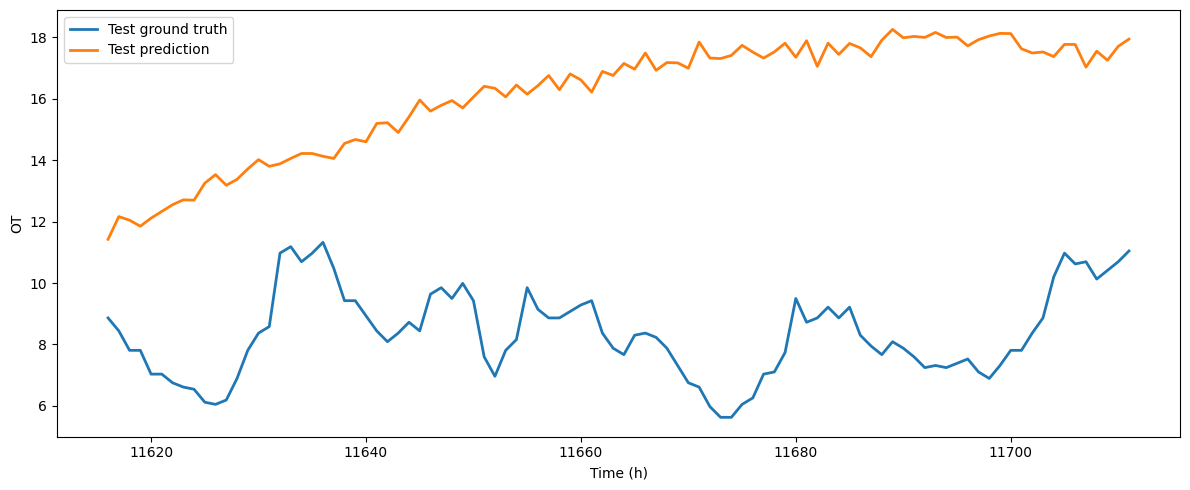

In [46]:
### Plot the results
plt.figure(figsize=(12, 5))

# Target values in the test set
plt.plot(
    time,
    y_test_targets[0],
    linewidth=2,
    label="Test ground truth",
    color="tab:blue",
)

# Predicted complete test region
plt.plot(
    time,
    y_test_predictions[0],
    linewidth=2,
    label="Test prediction",
    color="tab:orange",
)

plt.xlabel("Time (h)")
plt.ylabel("OT")

plt.legend()
plt.tight_layout()
plt.show()